In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random

def linear_regression(x, y):
    n = len(x)

    x_mean = sum(x) / n
    y_mean = sum(y) / n
    numerator = 0
    denominator = 0

    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean)
        denominator += (x[i] - x_mean) ** 2

    m = numerator / denominator
    b = y_mean - m * x_mean

    return m, b

In [16]:
# Data points
X = np.zeros(np.random.randint(10,20))
for i in range(0, len(X)):
    X[i] = np.random.uniform(0,50)
X = np.sort(X)

Y = np.zeros(len(X))
for i in range(0, len(Y)):
    Y[i] = np.random.uniform(0,50)

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Python Slope: {m}, Intercept: {c}")
m, c = linear_regression(X, Y)
print(f"Self-Implemented Slope: {m}, Intercept: {c}")

Python Slope: -0.2772909171330435, Intercept: 25.977334901942488
Self-Implemented Slope: -0.2772909171330436, Intercept: 25.9773349019425


Real Slope: 1, Real Intercept: 4
Lstsq Slope: 1.0980162261144695, Lstsq Intercept: 3.994533569313957
my versus python difference in slope: 1.1102230246251565e-15
my versus python difference in intercept: 1.1102230246251565e-15
Residuals:
[0.77795528 0.20927782 0.45733242 0.8868724  0.83455586 0.64959132
 0.67954443 0.46267098 0.99094955 0.5241672  0.21240566 0.73331071
 0.53861052 0.48353943 0.72122864 0.52482746 0.09785255 0.84717472
 0.34359066 0.27851863 0.30049569 0.696573   0.96139564 0.7620702
 0.06036417 0.51725615 0.37746415 0.81288549 0.5589581  0.59617894
 0.55750997 0.22191129 0.88895155 0.11203263 0.34735143 0.85132107
 0.34093359 0.38787093 0.03795172 0.36862807 0.44675001 0.34459394
 0.73566292 0.6667724  0.43533435 0.10485469 0.82852275 0.1616502
 0.10486115 0.37075568 0.31405369 0.2380445  0.20979771 0.60464633
 0.73777986 0.70044058 0.44077644 0.79579584 0.89166452 0.4264184
 0.09264603 0.64825746 0.94072158 0.85215538 0.63716648 0.56719918
 0.1058338  0.56705872 0.630

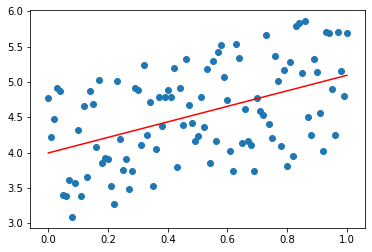

In [17]:
real_m = random.randint(1, 5)
real_c = random.randint(1, 5)

x = np.linspace(0, 1, 101)
y = np.zeros(len(x))
for i in range(0, len(x)):
    y[i] = real_m * x[i] + real_c + np.random.uniform(-1, 1)

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([x, np.ones(len(x))]).T

# Solve using least squares
py_m, py_c = np.linalg.lstsq(A, y, rcond=None)[0]
my_m, my_c = linear_regression(x, y)
print(f"Real Slope: {real_m}, Real Intercept: {real_c}")
print(f"Lstsq Slope: {my_m}, Lstsq Intercept: {my_c}")
plt.plot(x, my_m * x + my_c, 'r-')
plt.scatter(x, y)


print("my versus python difference in slope:", np.abs(my_m - py_m))
print("my versus python difference in intercept:", np.abs(my_m-py_m))

Resid = np.abs(y - (x*my_m + my_c))
print('Residuals:')
print(Resid)
print('Max Resid:', np.max(Resid), '@', np.argmax(Resid)/100.0)
print('Min Resid:', np.min(Resid), '@', np.argmin(Resid)/100.0)